In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
df=pd.read_csv('train (1).csv')
df

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [128]:
df.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


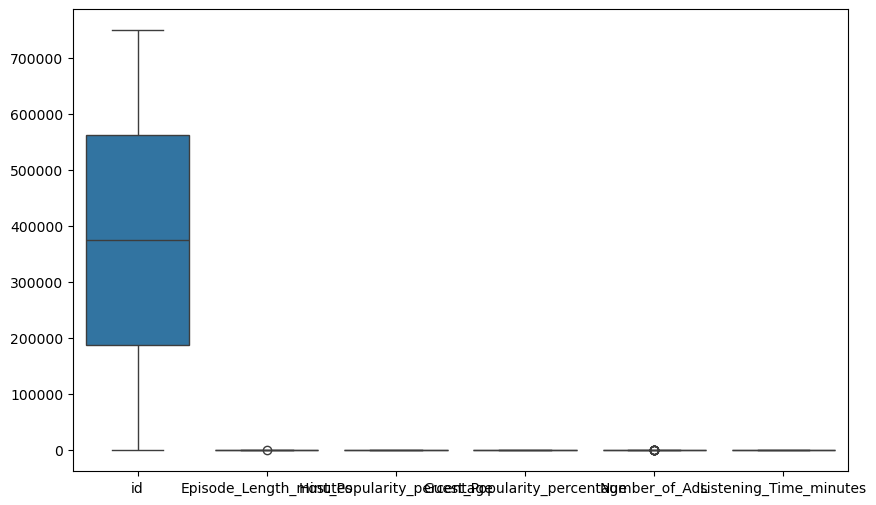

In [129]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.show()

In [130]:
df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [131]:
Episode_length_median=df['Episode_Length_minutes'].median()
Guest_Popularity_percentage_median=df['Guest_Popularity_percentage'].median()
Number_of_Ads_median=df['Number_of_Ads'].median()

df['Episode_Length_minutes'].fillna(Episode_length_median, inplace=True)
df['Episode_Length_minutes'] = df['Episode_Length_minutes'].astype(float)

df['Guest_Popularity_percentage'].fillna(Guest_Popularity_percentage_median, inplace=True)
df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].astype(float)

df['Number_of_Ads'].fillna(Number_of_Ads_median, inplace=True)
df['Number_of_Ads'] = df['Number_of_Ads'].astype(int)


C:\Users\DELL\AppData\Local\Temp\ipykernel_3664\4124518754.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Episode_Length_minutes'].fillna(Episode_length_median, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_3664\4124518754.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [132]:
df.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64

In [133]:
def cap_outlier(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower = Q1 - 1.5*IQR
    Upper = Q3 + 1.5*IQR
    df[column]=df[column].clip(Lower,Upper) #fill the outliers with the upper and lower bound values

cap_outlier('Episode_Length_minutes')
cap_outlier('Number_of_Ads')


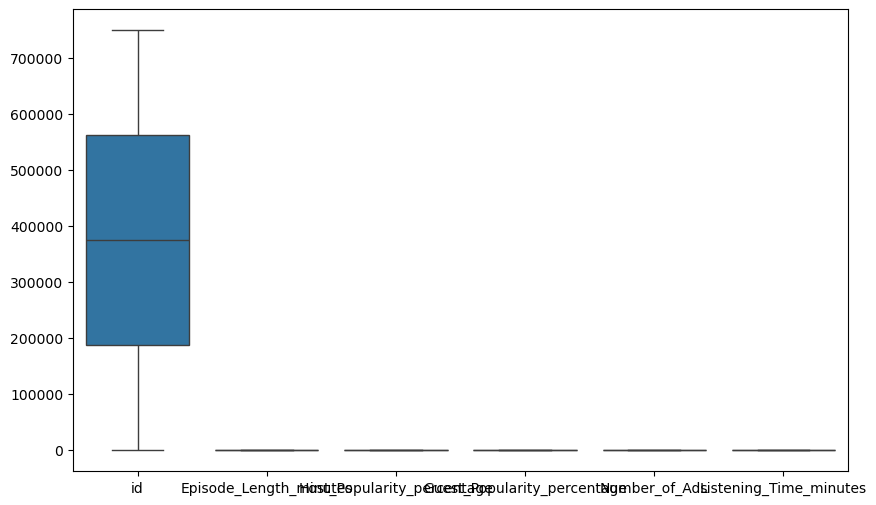

In [134]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.show()

In [135]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,63.84,True Crime,74.81,Thursday,Night,53.58,0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3,Neutral,75.61031


In [136]:
# Check unique values in each column
print(df.nunique())


id                             750000
Podcast_Name                       48
Episode_Title                     100
Episode_Length_minutes          12268
Genre                              10
Host_Popularity_percentage       8038
Publication_Day                     7
Publication_Time                    4
Guest_Popularity_percentage     10019
Number_of_Ads                       5
Episode_Sentiment                   3
Listening_Time_minutes          42807
dtype: int64


In [137]:
# Mapping Days and Sentiment
day_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

df['Publication_Day'] = df['Publication_Day'].map(day_map)
df['Episode_Sentiment'] = df['Episode_Sentiment'].map(sentiment_map)


In [138]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,63.84,True Crime,74.81,4,Night,53.58,0,2,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,6,Afternoon,75.95,2,0,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,2,Evening,8.97,0,0,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,1,Morning,78.70,2,2,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,1,Afternoon,58.68,3,1,75.61031


In [139]:
df = df.drop(columns=['id', 'Episode_Title'])

In [140]:
df.head()

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,63.84,True Crime,74.81,4,Night,53.58,0,2,31.41998
1,Joke Junction,119.80,Comedy,66.95,6,Afternoon,75.95,2,0,88.01241
2,Study Sessions,73.90,Education,69.97,2,Evening,8.97,0,0,44.92531
3,Digital Digest,67.17,Technology,57.22,1,Morning,78.70,2,2,46.27824
4,Mind & Body,110.51,Health,80.07,1,Afternoon,58.68,3,1,75.61031


In [141]:
df = pd.get_dummies(df, columns=['Publication_Time', 'Genre',['Podcast_Name'])

In [142]:
def convert(col):
    df[col] = df[col].map({True:1,False:0})

columns=['Publication_Time_Afternoon','Publication_Time_Evening','Publication_Time_Morning','Publication_Time_Night','Genre_Business','Genre_Comedy','Genre_Education','Genre_Health','Genre_Lifestyle','Genre_Music','Genre_News','Genre_Sports','Genre_Technology','Genre_True Crime']
for col in columns:
    convert(col)

In [143]:
df.head()

,Podcast_Name,Episode_Length_minutes,Host_Popularity_percentage,Publication_Day,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Publication_Time_Afternoon,Publication_Time_Evening,...,Genre_Business,Genre_Comedy,Genre_Education,Genre_Health,Genre_Lifestyle,Genre_Music,Genre_News,Genre_Sports,Genre_Technology,Genre_True Crime
0,Mystery Matters,63.84,74.81,4,53.58,0,2,31.41998,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Joke Junction,119.80,66.95,6,75.95,2,0,88.01241,1,0,...,0,1,0,0,0,0,0,0,0,0
2,Study Sessions,73.90,69.97,2,8.97,0,0,44.92531,0,1,...,0,0,1,0,0,0,0,0,0,0
3,Digital Digest,67.17,57.22,1,78.70,2,2,46.27824,0,0,...,0,0,0,0,0,0,0,0,1,0
4,Mind & Body,110.51,80.07,1,58.68,3,1,75.61031,1,0,...,0,0,0,1,0,0,0,0,0,0


In [144]:
df.shape

(750000, 22)

In [146]:
df.columns

Index(['Podcast_Name', 'Episode_Length_minutes', 'Host_Popularity_percentage',
       'Publication_Day', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment', 'Listening_Time_minutes',
       'Publication_Time_Afternoon', 'Publication_Time_Evening',
       'Publication_Time_Morning', 'Publication_Time_Night', 'Genre_Business',
       'Genre_Comedy', 'Genre_Education', 'Genre_Health', 'Genre_Lifestyle',
       'Genre_Music', 'Genre_News', 'Genre_Sports', 'Genre_Technology',
       'Genre_True Crime'],
      dtype='object')